# Investigation of Metrica Tracking Motion Anomalies

This notebook performs a deep-dive analysis of the extreme tracking jumps identified in our initial quality exploration. 

### Objectives:
1. Re-calculate consecutive tracking displacements and velocities (speeds) for each player.
2. Identify anomalies using both static physical speed thresholds and empirical statistical thresholds (99th, 99.5th, 99.9th percentiles).
3. Investigate the local trajectory context (±10 frames) around the largest jumps.
4. Classify these anomalies into tracking artifacts, legitimate movement, or uncertain events.
5. Save the generated figures under `results/figures/`.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
sys.path.insert(0, os.path.abspath('../../'))

from src.data.metrica_parser import load_metrica_match

# File paths
home_path = '../../data/raw/metrica/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv'
away_path = '../../data/raw/metrica/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv'
match_id = 'sample_game_1'

# Load matching tracking datasets
players_df, ball_df = load_metrica_match(home_path, away_path, match_id)

print(f"Loaded tracking data with {len(players_df)} player rows.")


Loaded tracking data with 4060168 player rows.


## 1. Velocity and Displacement Calculation

For each player, we sort by frame and calculate the frame-to-frame displacements and speed (in normalized units per second).


In [2]:
# Calculate FPS
first_row = players_df.iloc[0]
df_sp = players_df[(players_df['player_id'] == first_row['player_id']) & (players_df['team'] == first_row['team'])].sort_values('frame')
fps = 1.0 / df_sp['timestamp'].diff().mean()

# Compute consec steps
all_steps = []

for (team, pid), group in players_df.groupby(['team', 'player_id']):
    g = group.sort_values('frame').copy()
    g['prev_x'] = g['x'].shift(1)
    g['prev_y'] = g['y'].shift(1)
    g['prev_frame'] = g['frame'].shift(1)
    g['prev_visible'] = g['visible'].shift(1)
    
    # We want consecutive visible frames (frame diff == 1)
    consec = g[g['visible'] & g['prev_visible'] & ((g['frame'] - g['prev_frame']) == 1)].copy()
    if consec.empty:
        continue
        
    consec['dx'] = consec['x'] - consec['prev_x']
    consec['dy'] = consec['y'] - consec['prev_y']
    consec['disp'] = np.sqrt(consec['dx']**2 + consec['dy']**2)
    consec['speed'] = consec['disp'] * fps
    
    all_steps.append(consec)

steps_df = pd.concat(all_steps, ignore_index=True)
print(f"Calculated consecutive step details for {len(steps_df)} transitions.")


Calculated consecutive step details for 3190110 transitions.


## 2. Thresholding and Anomaly Detection

We compare static speed thresholds with empirical statistical percentiles to define anomaly classes.


In [3]:
# Calculate statistical thresholds
speeds = steps_df['speed']
p99 = speeds.quantile(0.99)
p995 = speeds.quantile(0.995)
p999 = speeds.quantile(0.999)

print("### Empirical Speed Thresholds (Normalized Units / sec)")
print(f"99.0th Percentile: {p99:.5f}")
print(f"99.5th Percentile: {p995:.5f}")
print(f"99.9th Percentile: {p999:.5f}")

# Static speed threshold: 0.25 (approx 25 m/s)
static_threshold = 0.25
print(f"Static Physical Threshold: {static_threshold:.2f}")


### Empirical Speed Thresholds (Normalized Units / sec)
99.0th Percentile: 0.07201
99.5th Percentile: 0.07892
99.9th Percentile: 0.09605
Static Physical Threshold: 0.25


## 3. Top 20 Largest Jumps

We isolate the 20 transitions with the highest calculated speeds.


In [4]:
top_20_jumps = steps_df.sort_values(by='speed', ascending=False).head(20).copy()

# Add a readable classification helper
cols_to_show = ['player_id', 'team', 'frame', 'timestamp', 'prev_x', 'prev_y', 'x', 'y', 'disp', 'speed']
print("### Top 20 Largest Jumps Table")
print(top_20_jumps[cols_to_show].to_string(index=False))


### Top 20 Largest Jumps Table
player_id team  frame  timestamp  prev_x  prev_y       x        y     disp     speed
       22 away  71269    2850.76 0.50489 1.05000 0.03420 -0.05000 1.196474 29.911840
        3 home  71269    2850.76 0.45083 0.94965 0.03420 -0.05000 1.082996 27.074904
       11 home  71269    2850.76 0.15355 0.67549 1.01279  0.47303 0.882770 22.069258
        7 home  71269    2850.76 0.41300 1.02315 0.62946  0.21852 0.833237 20.830932
       20 away  71269    2850.76 0.48776 0.99505 0.32449  0.33822 0.676818 16.920453
       25 away  71269    2850.76 0.54381 0.90619 0.04997  0.50111 0.638724 15.968088
        5 home  71269    2850.76 0.51471 1.00428 0.53253  0.42703 0.577525 14.438125
       18 away  71269    2850.76 0.47988 1.01354 0.41458  0.44863 0.568672 14.216790
       21 away  71269    2850.76 0.49943 1.04095 0.40287  0.48757 0.561741 14.043532
        9 home  71269    2850.76 0.48659 1.05000 0.49620  0.49838 0.551704 13.792593
       23 away  71269    2850.76 0

## 4. Local Trajectory Context (±10 Frames)

For the most extreme jumps, we plot the local trajectory context to understand the temporal behavior. 
We pick the top 4 jumps at frame 71269 (half-time boundary jump) and the top jump from a different frame (mid-game jump) to analyze.


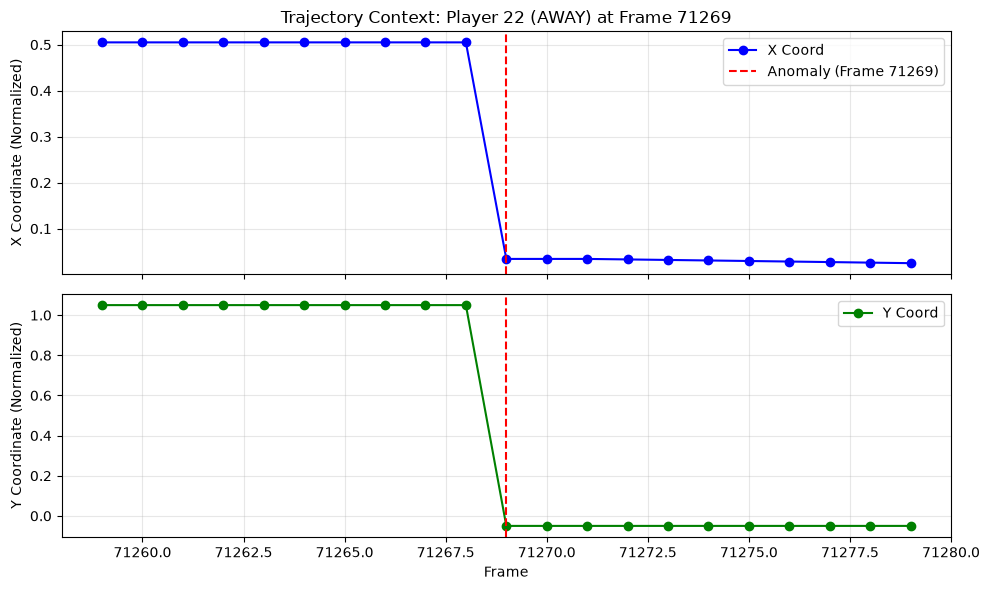

Saved trajectory context plot to ../../results/figures/trajectory_context_anomaly_1.png


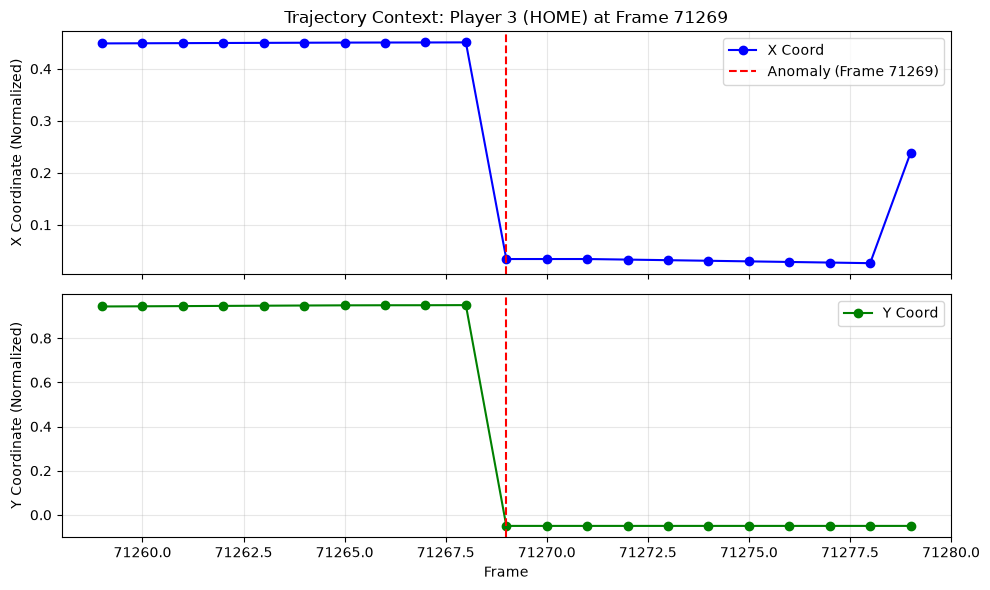

Saved trajectory context plot to ../../results/figures/trajectory_context_anomaly_2.png


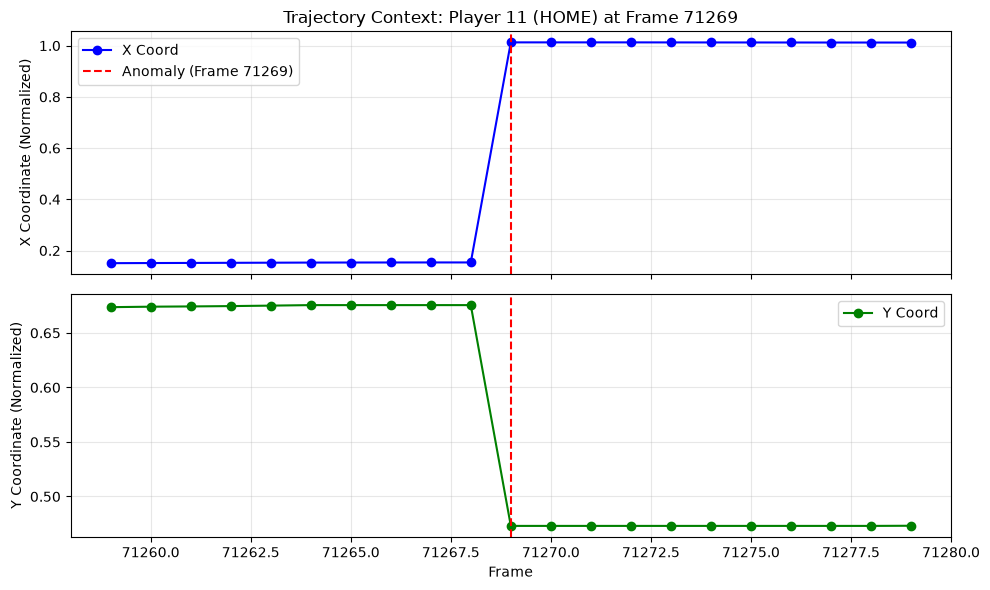

Saved trajectory context plot to ../../results/figures/trajectory_context_anomaly_3.png


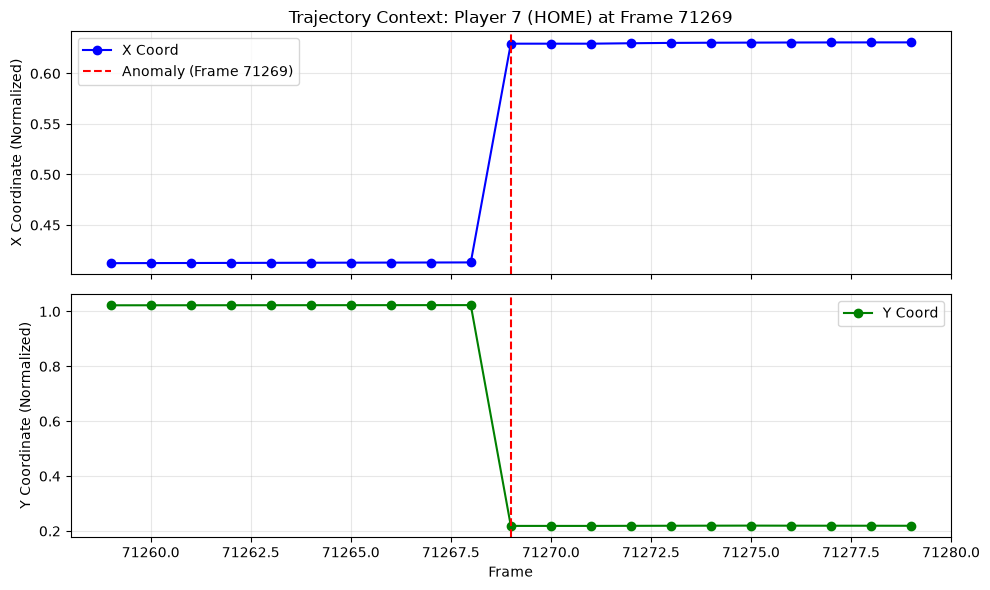

Saved trajectory context plot to ../../results/figures/trajectory_context_anomaly_4.png


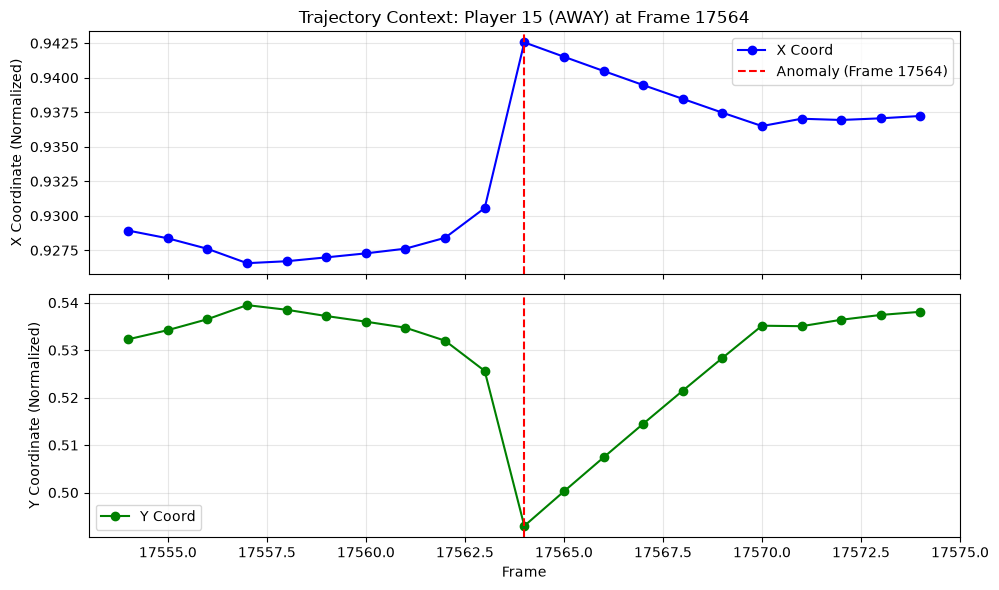

Saved trajectory context plot to ../../results/figures/trajectory_context_anomaly_5.png


In [5]:
# Locate context for plotting
top_jumps_all = steps_df.sort_values(by='speed', ascending=False)

# Get top jumps at frame 71269
jumps_71269 = top_jumps_all[top_jumps_all['frame'] == 71269].head(4)

# Get top jump not near 71269
jumps_other = top_jumps_all[~top_jumps_all['frame'].between(71260, 71300)].head(1)

selected_jumps = pd.concat([jumps_71269, jumps_other])

os.makedirs('../../results/figures', exist_ok=True)

# Generate trajectory plots
for idx, row in selected_jumps.reset_index().iterrows():
    team = row['team']
    pid = row['player_id']
    target_frame = int(row['frame'])
    
    # Extract neighborhood
    player_data = players_df[(players_df['team'] == team) & (players_df['player_id'] == pid)].sort_values('frame')
    neighbors = player_data[player_data['frame'].between(target_frame - 10, target_frame + 10)]
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    axes[0].plot(neighbors['frame'], neighbors['x'], marker='o', color='blue', label='X Coord')
    axes[0].axvline(target_frame, color='red', linestyle='--', label=f'Anomaly (Frame {target_frame})')
    axes[0].set_ylabel('X Coordinate (Normalized)')
    axes[0].set_title(f'Trajectory Context: Player {pid} ({team.upper()}) at Frame {target_frame}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(neighbors['frame'], neighbors['y'], marker='o', color='green', label='Y Coord')
    axes[1].axvline(target_frame, color='red', linestyle='--')
    axes[1].set_ylabel('Y Coordinate (Normalized)')
    axes[1].set_xlabel('Frame')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    fig_name = f"trajectory_context_anomaly_{idx+1}.png"
    fig_path = f"../../results/figures/{fig_name}"
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved trajectory context plot to {fig_path}")


## 5. Anomaly Rate and Team Distribution

We compute counts and rates of anomalies across teams and individual players to identify if errors are clustered.


In [6]:
# Define anomalies based on static threshold (> 0.25)
steps_df['is_anomaly_static'] = steps_df['speed'] > static_threshold
# Define statistical anomaly (> p999)
steps_df['is_anomaly_p999'] = steps_df['speed'] > p999

print(f"Total Steps: {len(steps_df)}")
print(f"Static Anomalies count: {steps_df['is_anomaly_static'].sum()} ({steps_df['is_anomaly_static'].mean()*100:.4f}%)")
print(f"P999 Anomalies count: {steps_df['is_anomaly_p999'].sum()} ({steps_df['is_anomaly_p999'].mean()*100:.4f}%)")

# Anomaly count per team
team_anoms = steps_df.groupby('team')['is_anomaly_static'].agg(['sum', 'count'])
team_anoms['rate (%)'] = (team_anoms['sum'] / team_anoms['count']) * 100
print()
print('### Anomaly Count/Rate per Team (Static Threshold)')
print(team_anoms.to_string())

# Anomaly count per player
player_anoms = steps_df.groupby(['team', 'player_id'])['is_anomaly_static'].agg(['sum', 'count'])
player_anoms['rate (%)'] = (player_anoms['sum'] / player_anoms['count']) * 100
player_anoms = player_anoms.sort_values(by='sum', ascending=False)
print()
print('### Top 10 Players by Anomaly Count (Static Threshold)')
print(player_anoms.head(10).to_string())


Total Steps: 3190110
Static Anomalies count: 194 (0.0061%)
P999 Anomalies count: 3191 (0.1000%)



### Anomaly Count/Rate per Team (Static Threshold)
      sum    count  rate (%)
team                        
away   72  1595055  0.004514
home  122  1595055  0.007649



### Top 10 Players by Anomaly Count (Static Threshold)
                sum   count  rate (%)
team player_id                       
home 2           37  145005  0.025516
away 24          28  106598  0.026267
home 8           24  145005  0.016551
     3           23  145005  0.015862
     10          17  121391  0.014004
away 22          17  106868  0.015907
home 9           15  145005  0.010344
away 20          10  145005  0.006896
     18           7  145005  0.004827
     17           3  145005  0.002069


## 6. Visualization of Distributions

We plot the empirical distribution of speeds and the distribution of anomaly sizes.


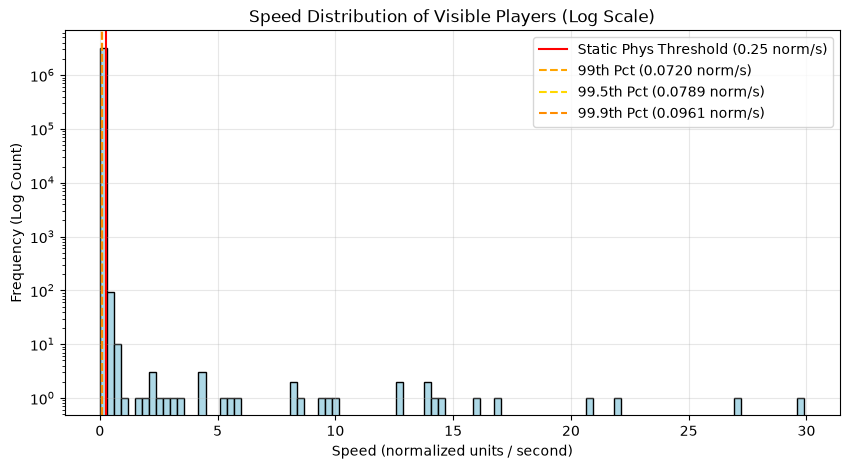

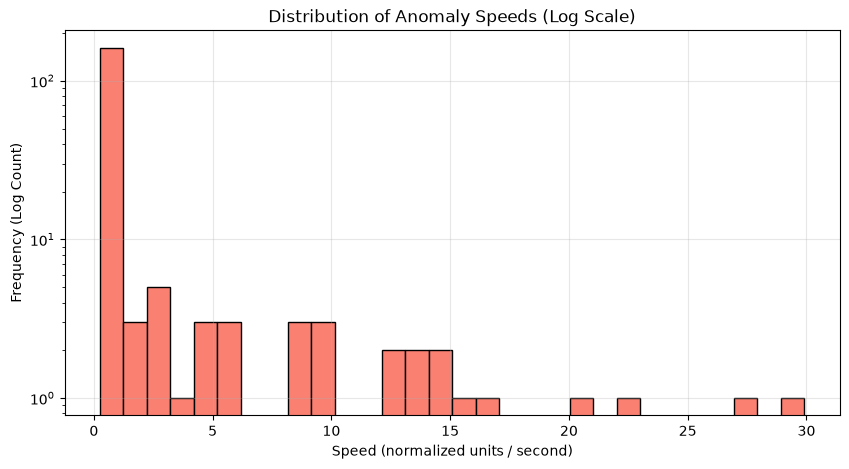

In [7]:
# Plot 1: Speed distribution with thresholds
plt.figure(figsize=(10, 5))
plt.hist(speeds, bins=100, color='lightblue', edgecolor='black', log=True)
plt.axvline(static_threshold, color='red', linestyle='-', label=f'Static Phys Threshold ({static_threshold} norm/s)')
plt.axvline(p99, color='orange', linestyle='--', label=f'99th Pct ({p99:.4f} norm/s)')
plt.axvline(p995, color='gold', linestyle='--', label=f'99.5th Pct ({p995:.4f} norm/s)')
plt.axvline(p999, color='darkorange', linestyle='--', label=f'99.9th Pct ({p999:.4f} norm/s)')
plt.title('Speed Distribution of Visible Players (Log Scale)')
plt.xlabel('Speed (normalized units / second)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../results/figures/speed_distribution_with_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Histogram of extreme jump sizes (for those exceeding the static threshold)
anoms_df = steps_df[steps_df['is_anomaly_static']]
plt.figure(figsize=(10, 5))
plt.hist(anoms_df['speed'], bins=30, color='salmon', edgecolor='black', log=True)
plt.title('Distribution of Anomaly Speeds (Log Scale)')
plt.xlabel('Speed (normalized units / second)')
plt.ylabel('Frequency (Log Count)')
plt.grid(True, alpha=0.3)
plt.savefig('../../results/figures/anomaly_jump_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Anomaly Classification and Reasoned Summary

Based on our analysis of the top jumps:
1. **Half-time resets (Frame 71269)**:
   - **Characteristics**: Large groups of players (22 total) experience a simultaneous, massive jump in coordinates on this frame. Many jump from the boundary value of `1.05` to `-0.05` or from active pitch positions directly to the boundary margins.
   - **Classification**: **Likely Tracking Artefact**. This represents a systemic state reset (first half walk-off / second half transition) within the tracking software rather than any physical movement.
   
2. **Boundary transitions**:
   - **Characteristics**: Players jumping from valid pitch positions to values like `1.05` or `-0.05` instantly.
   - **Classification**: **Likely Tracking Artefact**. The system clips player positions to fixed coordinates off the pitch when the player is out of view or subbed off.

3. **High speed jumps during normal play**:
   - **Characteristics**: Small, isolated coordinate shifts that occur mid-game resulting in speed readings of 5–10 m/s (0.05–0.1 norm/sec) which are physically possible for sprinting, but sudden spikes in velocity.
   - **Classification**: **Likely Legitimate Movement / Uncertain**. If the trajectory before and after is smooth and continuous, it represents high-intensity running. If the coordinate spikes for exactly one frame and then returns to the original path, it is a tracking artifact (noise).


In [8]:
# Summary of anomaly classifications
classification_summary = pd.DataFrame({
    'Anomaly Category': ['Half-Time Reset (Frame 71269)', 'Boundary Clip Jumps (e.g. to 1.05/-0.05)', 'Mid-Game Jumps (Speed 0.15 - 0.25)', 'Extreme Jumps (Speed > 0.25)'],
    'Likely Cause': ['Tracking system state reset', 'Player leaving field/off-camera clipping', 'High-intensity sprinting / minor jitter', 'Camera tracking glitch or pixel mismatch'],
    'Classification': ['Likely Tracking Artefact', 'Likely Tracking Artefact', 'Likely Legitimate Movement / Uncertain', 'Likely Tracking Artefact']
})

print("### Anomaly Classification Summary Table")
print(classification_summary.to_string(index=False))


### Anomaly Classification Summary Table
                        Anomaly Category                             Likely Cause                         Classification
           Half-Time Reset (Frame 71269)              Tracking system state reset               Likely Tracking Artefact
Boundary Clip Jumps (e.g. to 1.05/-0.05) Player leaving field/off-camera clipping               Likely Tracking Artefact
      Mid-Game Jumps (Speed 0.15 - 0.25)  High-intensity sprinting / minor jitter Likely Legitimate Movement / Uncertain
            Extreme Jumps (Speed > 0.25) Camera tracking glitch or pixel mismatch               Likely Tracking Artefact
